A test to see which number is more suitable for set_num_threads

In [ ]:
# import torch
# import time
#
# def benchmark_threads(num_threads, matrix_size=4000, iterations=20):
#     # Set the number of threads for this test run
#     torch.set_num_threads(num_threads)
#
#     # Create two massive random matrices to simulate deep learning workloads
#     A = torch.randn(matrix_size, matrix_size)
#     B = torch.randn(matrix_size, matrix_size)
#
#     # Warmup round (gets the CPU caches loaded and ready)
#     _ = torch.matmul(A, B)
#
#     # Start the actual timer
#     start_time = time.time()
#
#     # Run the heavy math multiple times
#     for _ in range(iterations):
#         _ = torch.matmul(A, B)
#
#     end_time = time.time()
#
#     print(f"Total time with {num_threads} threads: {end_time - start_time:.4f} seconds")
#
# print("--- PyTorch CPU Thread Benchmark ---")
# # Test with 4 threads
# benchmark_threads(4)
#
# # Test with 8 threads
# benchmark_threads(8)

8 threads is faster than 4 threads, so we will use 8 threads for the rest of the code

Cell 1: Imports and Device Setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import time
from ofdm.ccdf import plot_ccdf, plot_ccdf_compare
from ofdm.papr import calculate_papr

# Explicitly tell PyTorch to utilize your 8 CPU cores for matrix math
# Check for GPU availability to drastically speed up training
# ! cuda is available only on nvidia gpu
torch.set_num_threads(8)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch using {torch.get_num_threads()} threads on {device}")

PyTorch using 8 threads on cpu


Cell 1.5: Changing the data format from .npz to .pt for faster loading (one-time setup)

In [ ]:
# def normalize_and_save():
#     input_dir = "./16QAMdata/"
#     output_dir = "./16QAMpt/"
#     os.makedirs(output_dir, exist_ok=True)
#
#     print("Converting .npz to normalized .pt files...")
#     for i in range(100):
#         print(f"Processing file {i + 1}/100: 16qam_tx_rx_32_part_{i:03d}.npz")
#         # 1. Load the slow .npz file
#         try:
#             data = np.load(os.path.join(input_dir, f"16qam_tx_rx_32_part_{i:03d}.npz"))
#         except FileNotFoundError:
#             break
#         X_raw = data['tx']
#         Y_raw = data['rx']
#
#         # 2. Extract Real and Imaginary
#         for part_idx, part_name in enumerate(['real', 'imag']):
#             X_batch = torch.tensor(X_raw[part_idx, :, :], dtype=torch.float32)
#             Y_batch = torch.tensor(Y_raw[part_idx, :, :], dtype=torch.float32)
#
#             # 3. Normalize once and for all
#             X_min, X_max = X_batch.min(), X_batch.max()
#             Y_min, Y_max = Y_batch.min(), Y_batch.max()
#
#             X_norm = 2.0 * ((X_batch - X_min) / (X_max - X_min)) - 1.0 if X_max != X_min else X_batch
#             Y_norm = 2.0 * ((Y_batch - Y_min) / (Y_max - Y_min)) - 1.0 if Y_max != Y_min else Y_batch
#
#             # 4. Save as a hyper-fast PyTorch file
#             torch.save((X_norm, Y_norm), os.path.join(output_dir, f"16qam_tx_rx_32_part_{i:03d}_{part_name}.pt"))
#
#     print("Done! You never have to do this math again.")
#
# normalize_and_save()

Cell 2: Custom Activation Function

In [2]:
class TriangularActivation(nn.Module):
    """
    Implements the triangular activation function used in the paper's hidden layers.
    Mathematically equivalent to MATLAB's 'tribas': f(x) = max(1 - |x|, 0)
    """
    def forward(self, x):
        return torch.clamp(1.0 - torch.abs(x), min=0.0)

Cell 3: Highly Optimized Dataset Class

This is fast as it works with .pt directly without conversion

In [3]:
class FastOFDMDataset(Dataset):
    def __init__(self, pt_folder_path, part='real'):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return 100 # Assuming exactly 100 pre-computed .pt files

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        file_path = os.path.join(self.folder_path, f"16qam_tx_rx_32_part_{idx:03d}_{self.part}.pt")
        X_norm, Y_norm = torch.load(file_path, weights_only=True)
        return X_norm, Y_norm

Cell 4: Neural Network Architecture

In [4]:
class NNICFMapper(nn.Module):
    def __init__(self, input_size):
        super(NNICFMapper, self).__init__()
        # First hidden layer: 2 neurons
        self.hidden1 = nn.Linear(input_size, 2)
        # Second hidden layer: 1 neuron
        self.hidden2 = nn.Linear(2, 1)
        # Output layer: Maps back to the original subcarrier points
        self.output = nn.Linear(1, input_size)
        # Custom triangular activation
        self.activation = TriangularActivation()

    def forward(self, x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.output(x) # Standard linear output
        return x

Cell 5: Initialization and DataLoaders

In [5]:
# --- Configuration ---
# Update this path to where your 100 files are saved!
file_directory = "./16QAMpt/"

# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
train_dataset_real = FastOFDMDataset(file_directory, part='real')
train_loader_real = DataLoader(
    train_dataset_real,
    batch_size=None, # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=True,
    num_workers=0,   # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)

train_dataset_imag = FastOFDMDataset(file_directory, part='imag')
train_loader_imag = DataLoader(
    train_dataset_imag,
    batch_size=None,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# 1024 features based on N=256 and oversampling J=4
input_features = 1024

# Initialize models and send them to the GPU/device
Mod_Re_NN = NNICFMapper(input_features).to(device)
Mod_Im_NN = NNICFMapper(input_features).to(device)

# Standard Mean Squared Error loss and Adam optimizer
criterion = nn.MSELoss()
optimizer_real = optim.Adam(Mod_Re_NN.parameters(), lr=0.001)
optimizer_imag = optim.Adam(Mod_Im_NN.parameters(), lr=0.001)

Not using .compile() is actually better, it also avoids the hassle of cl.exe and needing to run "x64 Native Tools Command Prompt for VS".

dont know if thats the case with gpu or not tho

Cell 6: Training Loop (Real Module)

In [ ]:
# # * takes ~18m
# epochs = 100
# print("--- Starting Training for the Real NN Module ---")
# # ! if using .compile(), it is expected for the first epoch to take longer
# for epoch in range(epochs):
#     start = time.time()
#     epoch_loss = 0.0
#     Mod_Re_NN.train()
#
#     for X_batch, Y_batch in train_loader_real:
#         # Transfer data to GPU if possible
#         X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)
#
#         optimizer_real.zero_grad(set_to_none=True)
#         predictions = Mod_Re_NN(X_batch)
#         loss = criterion(predictions, Y_batch)
#
#         loss.backward()
#         optimizer_real.step()
#
#         epoch_loss += loss.item()
#
#     avg_loss = epoch_loss / len(train_loader_real)
#     end = time.time()
#     print(f"Real Module | Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Time: {end - start:.2f} seconds")
#
# print("Real NN Module Training Complete!")

Cell 7: Training Loop (Imaginary Module)

In [ ]:
# epochs = 100
# print("--- Starting Training for the Imaginary NN Module ---")
#
# for epoch in range(epochs):
#     start = time.time()
#     epoch_loss = 0.0
#     Mod_Im_NN.train()
#
#     for X_batch, Y_batch in train_loader_imag:
#         # Transfer data to GPU
#         X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)
#
#         optimizer_imag.zero_grad(set_to_none=True)
#         predictions = Mod_Im_NN(X_batch)
#         loss = criterion(predictions, Y_batch)
#
#         loss.backward()
#         optimizer_imag.step()
#
#         epoch_loss += loss.item()
#
#     avg_loss = epoch_loss / len(train_loader_imag)
#     end = time.time()
#     print(f"Imaginary Module | Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Time: {end - start:.2f} seconds")
#
# print("Imaginary NN Module Training Complete!")

Cell 8: Saving the Models

In [ ]:
# # Save the trained models
# save_dir = "./trained_models/"
# os.makedirs(save_dir, exist_ok=True)
# torch.save(Mod_Re_NN.state_dict(), os.path.join(save_dir, "mod_re_weights.pth"))
# torch.save(Mod_Im_NN.state_dict(), os.path.join(save_dir, "mod_im_weights.pth"))
# print("\nTraining complete and weights saved!")

Since we already saved the models, we can comment out most of the previous code blocks

Cell 9: Testing

In [6]:
# 1. Load the Saved Models
Test_Mod_Re = NNICFMapper(input_features).to(device)
Test_Mod_Im = NNICFMapper(input_features).to(device)

Test_Mod_Re.load_state_dict(torch.load("./trained_models/mod_re_weights.pth", weights_only=True))
Test_Mod_Im.load_state_dict(torch.load("./trained_models/mod_im_weights.pth", weights_only=True))

Test_Mod_Re.eval()
Test_Mod_Im.eval()

# 2. Grab one batch of data to test
test_X_real, _ = torch.load("./16QAMpt/16qam_tx_rx_32_part_000_real.pt", weights_only=True)
test_X_imag, _ = torch.load("./16QAMpt/16qam_tx_rx_32_part_000_imag.pt", weights_only=True)

# 3. Generate Predictions (No gradients needed for testing)
with torch.no_grad():
    predicted_real = Test_Mod_Re(test_X_real).numpy()
    predicted_imag = Test_Mod_Im(test_X_imag).numpy()

# 4. Reconstruct the Complex OFDM Signals
original_complex = test_X_real.numpy() + 1j * test_X_imag.numpy()
predicted_complex = predicted_real + 1j * predicted_imag

[ 6.107249   6.3269973  6.387224  ... 11.298336  11.324041  11.808801 ]
10000
[1.000e+00 9.999e-01 9.998e-01 ... 3.000e-04 2.000e-04 1.000e-04]


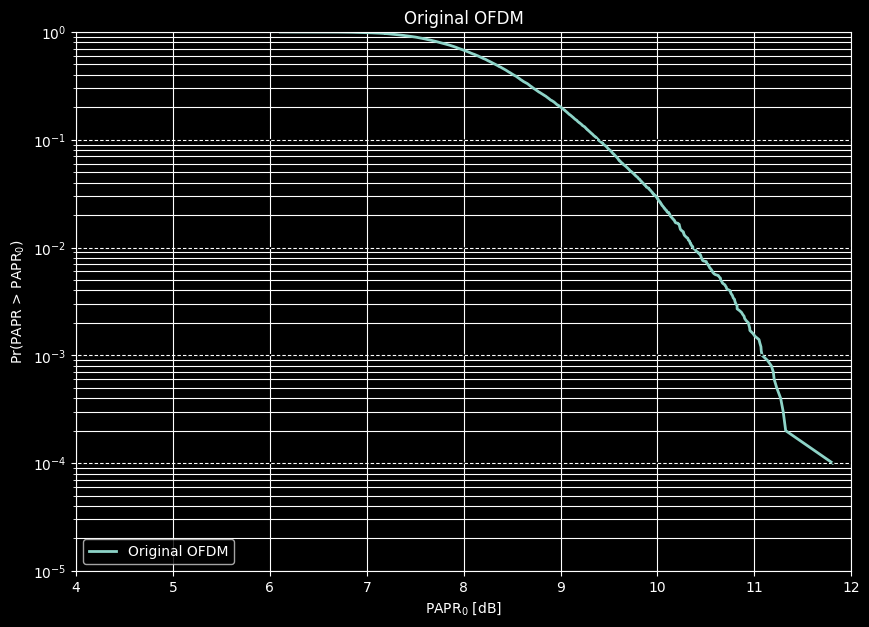

[2.087938  2.1135726 2.141563  ... 9.547411  9.548776  9.552618 ]
10000
[1.000e+00 9.999e-01 9.998e-01 ... 3.000e-04 2.000e-04 1.000e-04]


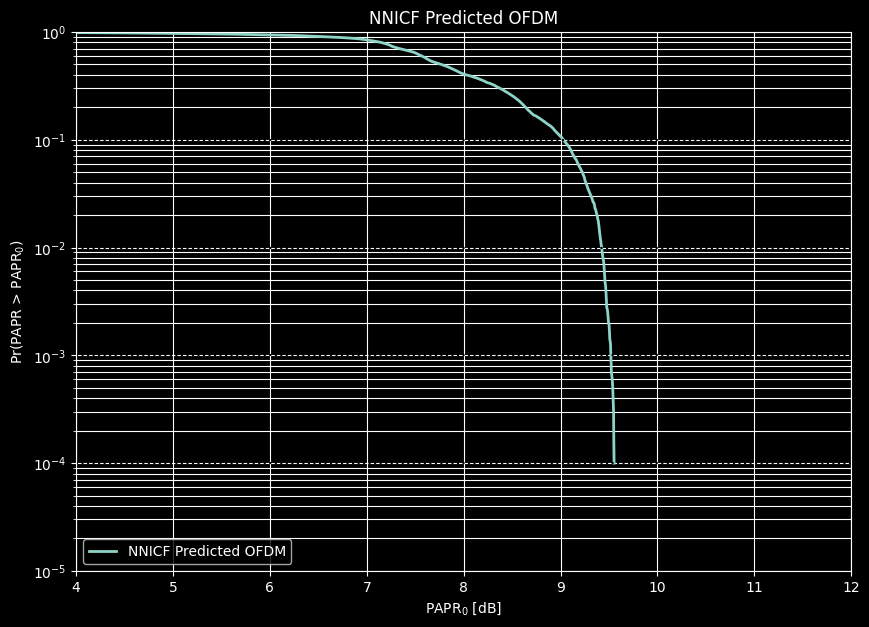

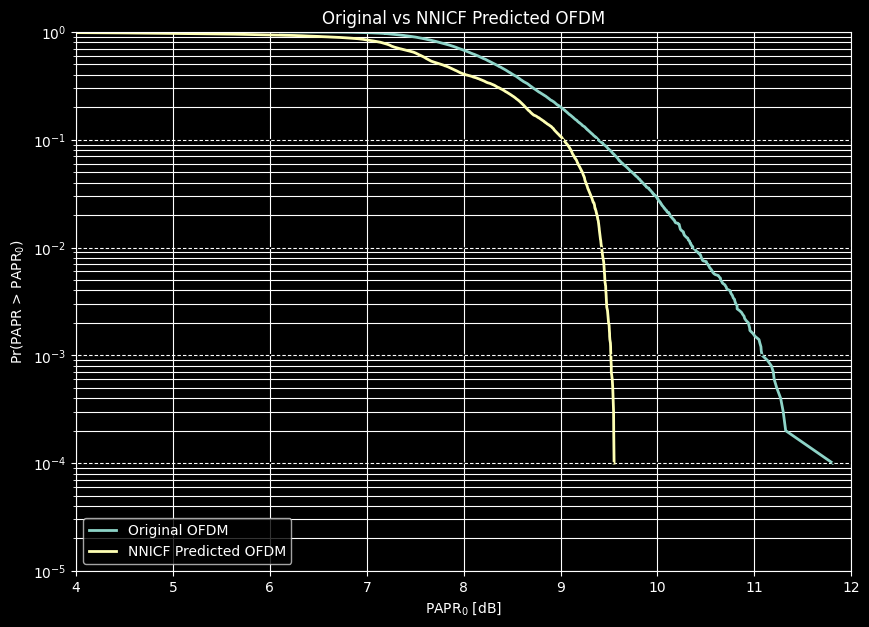

In [8]:
# 5. Calculate PAPR (Peak-to-Average Power Ratio) for CCDF
orig_papr = []
pred_papr = []
for i in range(len(original_complex)):
    orig_papr.append(calculate_papr(original_complex[i]))
    pred_papr.append(calculate_papr(predicted_complex[i]))
orig_papr = np.array(orig_papr)
pred_papr = np.array(pred_papr)

# 6. Plot the CCDF
plot_ccdf(orig_papr, 'Original OFDM')
plot_ccdf(pred_papr, 'NNICF Predicted OFDM')

labels = ['Original OFDM', 'NNICF Predicted OFDM']

plot_ccdf_compare([orig_papr, pred_papr], "Original vs NNICF Predicted OFDM", labels)